In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to path
sys.path.append(os.path.abspath(os.path.join('..')))

from src.core.fourier_transform import FourierTransformer
from src.core.reconstruction import Reconstructor
from src.utils.signal_generator import SignalGenerator

# Visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
print("Fourier Core Modules Loaded.")

Fourier Core Modules Loaded.


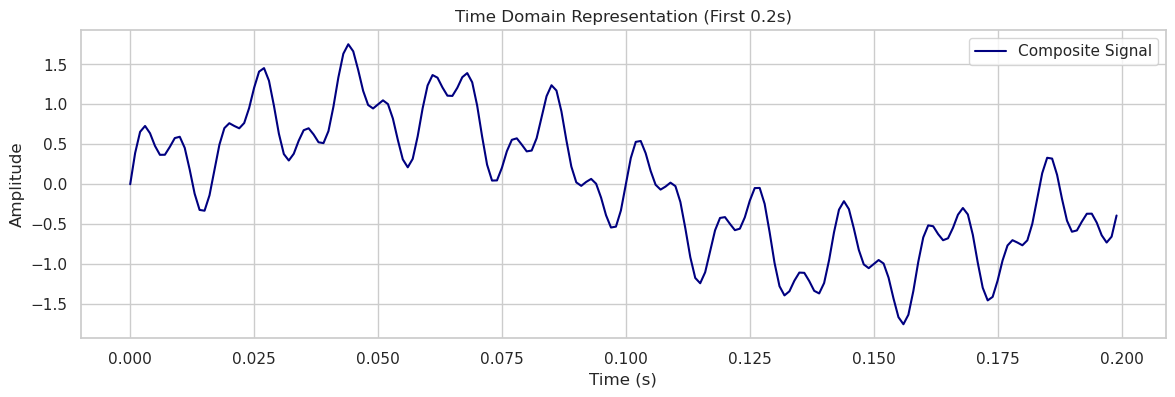

In [2]:
# Configuration
fs = 1000.0         # Sampling Rate (Hz)
duration = 1.0      # Duration (seconds)
gen = SignalGenerator(fs, duration)

# Create distinct components
# 1. Low frequency base (5 Hz)
sig_5hz = gen.sine_wave(freq=5, amplitude=1.0)
# 2. Medium frequency (50 Hz)
sig_50hz = gen.sine_wave(freq=50, amplitude=0.5)
# 3. High frequency noise (120 Hz)
sig_120hz = gen.sine_wave(freq=120, amplitude=0.3)

# Superposition: Combine them into one complex signal
composite_signal = sig_5hz + sig_50hz + sig_120hz
t = gen.t

# Plot Time Domain
plt.figure(figsize=(14, 4))
plt.plot(t[:200], composite_signal[:200], color='navy', label='Composite Signal')
plt.title("Time Domain Representation (First 0.2s)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

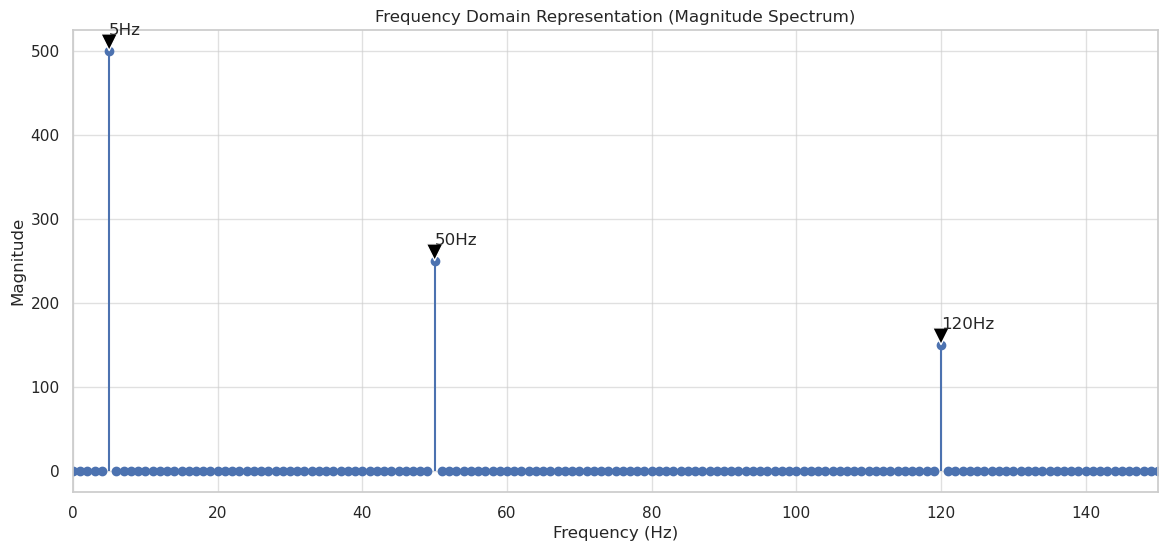

In [3]:
# Initialize Transformer
transformer = FourierTransformer(sampling_rate=fs)

# Compute FFT
spectrum = transformer.compute_fft(composite_signal)

# Extract data for plotting
freqs = spectrum.frequencies
mags = spectrum.magnitude

# Visualization: The Frequency Spectrum
plt.figure(figsize=(14, 6))
plt.stem(freqs, mags, basefmt=" ")
plt.title("Frequency Domain Representation (Magnitude Spectrum)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

# Limit x-axis to relevant range (0 to 150Hz) to see our components clearly
plt.xlim(0, 150)
plt.grid(True, which='both', alpha=0.6)

# Annotate peaks
for freq, mag in zip(freqs, mags):
    if mag > 50: # Threshold to filter tiny noise
        plt.annotate(f"{int(freq)}Hz", xy=(freq, mag), xytext=(freq, mag+20),
                     arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

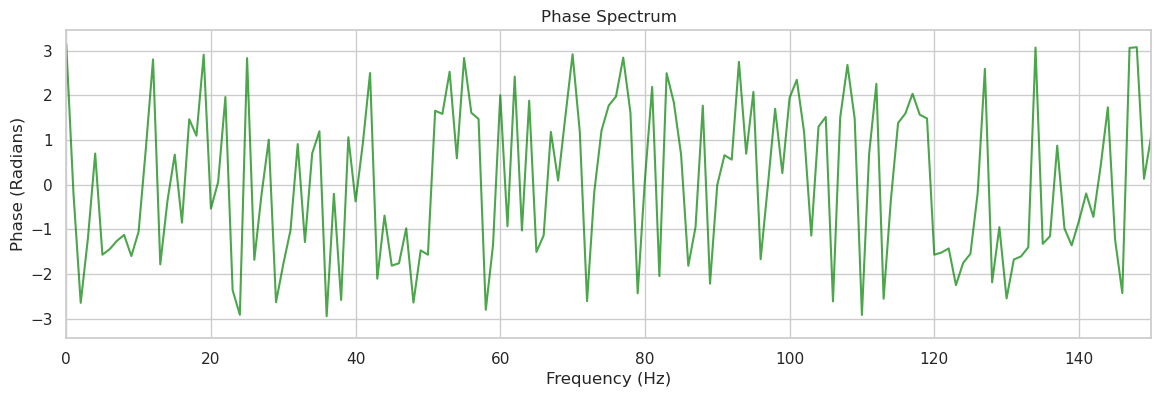

In [4]:
# Phase is crucial for reconstructing the signal's shape correctly
phase = spectrum.phase

plt.figure(figsize=(14, 4))
plt.plot(freqs, phase, color='green', alpha=0.7)
plt.title("Phase Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase (Radians)")
plt.xlim(0, 150)
plt.show()

Reconstruction Mean Squared Error (MSE): 0.0000000000


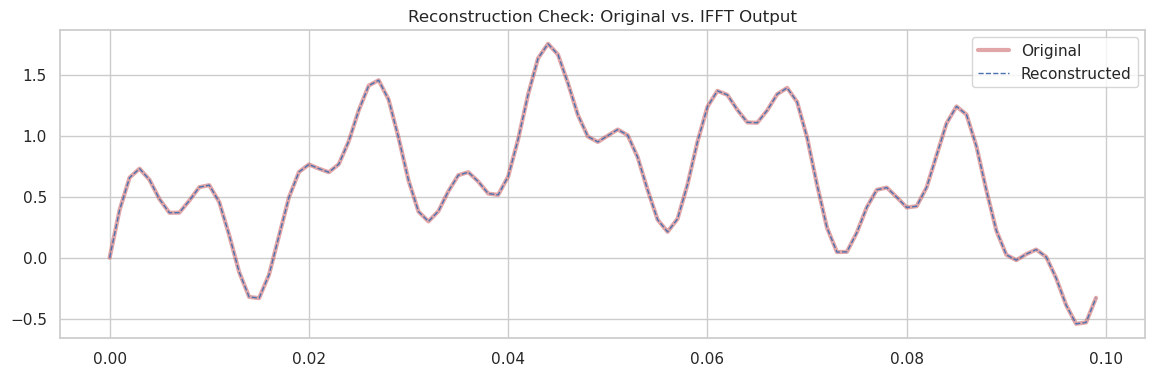

✅ SUCCESS: Perfect reconstruction verified.


In [5]:
# Initialize Reconstructor
reconstructor = Reconstructor(sampling_rate=fs)

# Perform Inverse Transform
reconstructed_signal = reconstructor.inverse_transform(spectrum.complex_spectrum)

# Calculate Error (MSE)
mse = reconstructor.calculate_mse(composite_signal, reconstructed_signal)

print(f"Reconstruction Mean Squared Error (MSE): {mse:.10f}")

# Visual Comparison
plt.figure(figsize=(14, 4))
plt.plot(t[:100], composite_signal[:100], 'r-', linewidth=3, alpha=0.5, label='Original')
plt.plot(t[:100], reconstructed_signal[:100], 'b--', linewidth=1, label='Reconstructed')
plt.title("Reconstruction Check: Original vs. IFFT Output")
plt.legend()
plt.show()

if mse < 1e-9:
    print("✅ SUCCESS: Perfect reconstruction verified.")
else:
    print("⚠️ WARNING: Reconstruction error detected.")